# 🛍️ GenAI-Powered Retail Sales Analytics Chatbot

This project presents a **GenAI-powered conversational analytics chatbot** designed to analyze retail sales data and provide intelligent insights through natural language interaction.

The system integrates **data analytics, SQLite database processing, and Large Language Models (LLMs)** to help users explore sales trends, product performance, and promotional impacts.

The chatbot allows users to **ask questions about sales performance** and receive **automatically generated business insights** along with supporting analytics results.

In [1]:
!pip install pandas groq

In [2]:
import pandas as pd
import sqlite3
import os
from groq import Groq
from datetime import datetime

In [3]:
# Load dataset

import pandas as pd

file_path = r"C:\Users\shali\OneDrive\Desktop\retail_chatbot\data\sales_data.xlsx"

df = pd.read_csv("fmcg_cleaned_data.csv")

df.head()

,product_name,sales_amount,transaction_month
0,Shampoo,2904,10
1,Detergent,4147,6
2,Soap,3561,10
3,Oil,2098,10
4,Shampoo,1863,4


In [4]:
import sqlite3

conn = sqlite3.connect("retail.db")
df.to_sql("sales_data", conn, if_exists="replace", index=False)

200

In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Convert month column
df['transaction_month'] = pd.to_datetime(df['transaction_month'])

# Feature engineering
df['Year'] = df['transaction_month'].dt.year
df['Month'] = df['transaction_month'].dt.month
df['Month_Name'] = df['transaction_month'].dt.month_name()

# Revenue column
df['total_revenue'] = df['sales_amount']

df.head()

,product_name,sales_amount,transaction_month,Year,Month,Month_Name,total_revenue
0,Shampoo,2904,1970-01-01 00:00:00.000000010,1970,1,January,2904
1,Detergent,4147,1970-01-01 00:00:00.000000006,1970,1,January,4147
2,Soap,3561,1970-01-01 00:00:00.000000010,1970,1,January,3561
3,Oil,2098,1970-01-01 00:00:00.000000010,1970,1,January,2098
4,Shampoo,1863,1970-01-01 00:00:00.000000004,1970,1,January,1863


In [6]:
conn = sqlite3.connect("sales.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

print("Database created successfully")

Database created successfully


In [7]:
def total_sales():

    query = """
    SELECT SUM(total_revenue) as total_revenue
    FROM sales
    """

    result = pd.read_sql(query, conn)
    return result

In [8]:
def monthly_sales():

    query = """
    SELECT Month_Name, SUM(total_revenue) as revenue
    FROM sales
    GROUP BY Month_Name
    """

    result = pd.read_sql(query, conn)
    return result

In [9]:
def top_product():

    query = """
    SELECT product_name,
    SUM(sales_amount) as revenue
    FROM sales
    GROUP BY product_name
    ORDER BY revenue DESC
    LIMIT 1
    """

    result = pd.read_sql(query, conn)

    return result

In [10]:
def chatbot(query):

    query = query.lower()

    if "total sales" in query:

        result = total_sales()

        return f"Total sales revenue is {result}"

    elif "monthly sales" in query:

        result = monthly_sales()

        return result.to_string()

    elif "top product" in query:

        result = top_product()

        return f"Top selling product is {result}"

    elif "product sales" in query:

        result = product_sales()

        return result.to_string()

    else:

        return "Sorry, I couldn't understand your question."


In [11]:
import sqlite3

conn = sqlite3.connect("sales.db")

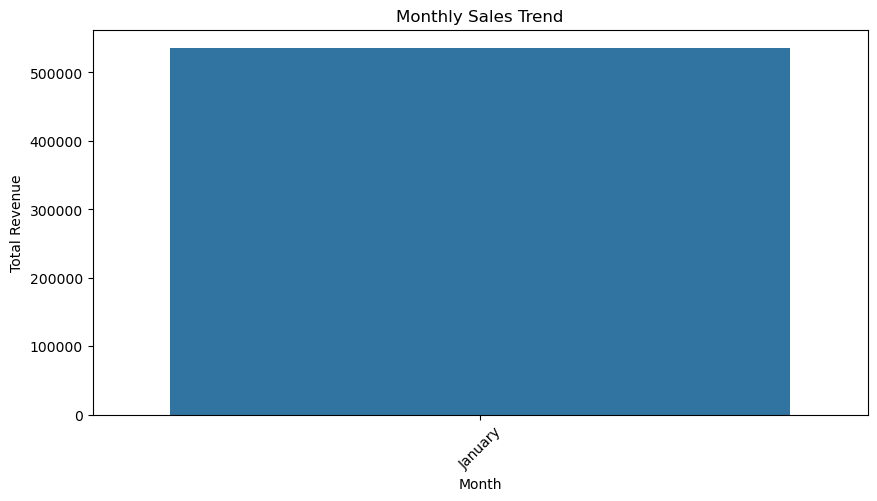

In [12]:
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# connect to database
conn = sqlite3.connect("sales.db")

query = """
SELECT Month_Name, SUM(total_revenue) as revenue
FROM sales
GROUP BY Month_Name
"""

monthly_sales = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly_sales,
    x="Month_Name",
    y="revenue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

In [13]:
def plot_monthly_sales():

    data = monthly_sales()

    plt.figure(figsize=(8,4))
    sns.lineplot(x="month",y="revenue",data=data)

    plt.title("Monthly Sales Trend")

    plt.show()

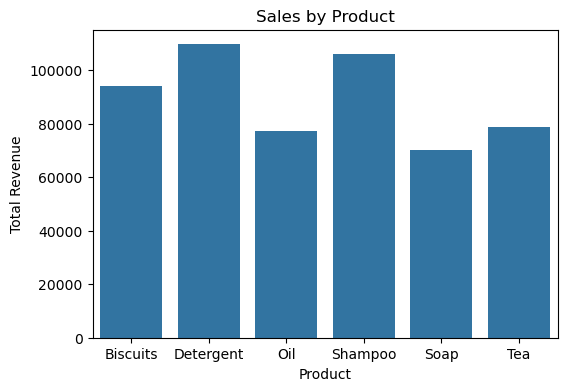

In [14]:
query = """
SELECT product_name, SUM(total_revenue) as revenue
FROM sales
GROUP BY product_name
"""

product_sales = pd.read_sql(query, conn)

plt.figure(figsize=(6,4))

sns.barplot(
    data=product_sales,
    x="product_name",
    y="revenue"
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")

plt.show()

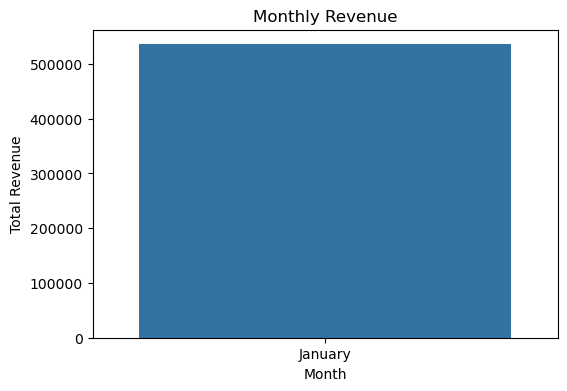

In [15]:
query = """
SELECT Month_Name, SUM(total_revenue) as revenue
FROM sales
GROUP BY Month_Name
"""

monthly_sales = pd.read_sql(query, conn)

plt.figure(figsize=(6,4))

sns.barplot(
    data=monthly_sales,
    x="Month_Name",
    y="revenue"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.show()

In [16]:
query = """
SELECT Year, SUM(total_revenue) as revenue
FROM sales
GROUP BY Year
"""

year_sales = pd.read_sql(query, conn)
print(year_sales)

   Year  revenue
0  1970   535769


In [17]:
query = "PRAGMA table_info(sales);"
pd.read_sql(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,product_name,TEXT,0,None,0
1,1,sales_amount,INTEGER,0,None,0
2,2,transaction_month,TIMESTAMP,0,None,0
3,3,Year,INTEGER,0,None,0
4,4,Month,INTEGER,0,None,0
5,5,Month_Name,TEXT,0,None,0
6,6,total_revenue,INTEGER,0,None,0


In [18]:
suggestions = [
"Show total sales",
"Show monthly sales trend",
"What is the top product?"
]

for s in suggestions:
    print("-",s)

- Show total sales
- Show monthly sales trend
- What is the top product?


In [19]:
def chatbot(query):

    query = query.lower()

    if "total sales" in query:
        return total_sales()

    elif "monthly sales" in query:
        return monthly_sales()
    else:
        return ai_response(query)

## 💾 Retail Sales Report Export

The final dataset, including product sales metrics and AI-generated insights, is exported for integration into business dashboards, reporting systems, or decision-making workflows.

This export allows analysts to review product performance, revenue trends, and monthly sales insights for further analysis or business reporting.

In [20]:
import os

# create folder if not exists
os.makedirs(r"D:\shalini_pwc\capstone_2", exist_ok=True)

# change working directory
os.chdir(r"D:\shalini_pwc\capstone_2")

print("Working directory:", os.getcwd())

Working directory: D:\shalini_pwc\capstone_2


In [21]:
import pandas as pd
import numpy as np

products = ["Soap","Shampoo","Biscuits","Tea","Oil","Detergent"]

df = pd.DataFrame({
    "product_name": np.random.choice(products, 200),
    "sales_amount": np.random.randint(500,5000,200),
    "transaction_month": np.random.randint(1,13,200)
})

df.to_csv("fmcg_cleaned_data.csv", index=False)

print("Dataset created successfully")

Dataset created successfully


# Deployment and Application Launch

## Streamlit Dashboard

To make the analysis easier to explore, the project is deployed using a Streamlit application.

The Streamlit app opens a simple dashboard in the browser where users can view sales information and charts.

When the notebook runs the Streamlit file, the dashboard launches automatically and displays the retail sales analysis.

Users can:

- view total sales and transaction metrics
- explore product performance
- check monthly sales trends
- interact with the dashboard through filters

This dashboard acts as the final layer of the project where the processed data and analysis are presented in a visual format.

In [22]:
%%writefile app.py

import streamlit as st
import pandas as pd
import time
from datetime import datetime
from groq import Groq
import os
from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
import tempfile
# -----------------------------
# PDF REPORT GENERATOR
# -----------------------------

def generate_pdf(chat_df):

    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix=".pdf")

    c = canvas.Canvas(temp_file.name, pagesize=letter)

    y = 750

    c.setFont("Helvetica", 12)

    c.drawString(50, y, "Retail AI Chat Report")

    y -= 40

    for index, row in chat_df.iterrows():

        text = f"User: {row['User Query']}"
        c.drawString(50, y, text)
        y -= 20

        text = f"Bot: {row['Bot Response']}"
        c.drawString(50, y, text)
        y -= 30

        if y < 100:
            c.showPage()
            y = 750

    c.save()

    return temp_file.name

# -----------------------------
# LOAD DATASET FIRST (VERY IMPORTANT)
# -----------------------------
df = pd.read_csv("fmcg_cleaned_data.csv")

cat = "product_name"
sales = "sales_amount"
date = "transaction_month"

df[date] = pd.to_datetime(df[date], format="%m", errors="coerce")

# -----------------------------
# SESSION STATE (CHAT MEMORY)
# -----------------------------
if "chat_history" not in st.session_state:
    st.session_state.chat_history = []

# -----------------------------
# GROQ AI CLIENT
# -----------------------------
from groq import Groq

# Replace with your Groq API key
GROQ_API_KEY = "GROQ_API_KEY"

client = Groq(api_key=GROQ_API_KEY)


# -----------------------------
# AI RESPONSE FUNCTION
# -----------------------------
def ai_response(question):

    try:

        completion = client.chat.completions.create(

            messages=[{
                "role": "user",
                "content": question
            }],

            model="llama-3.1-8b-instant"

        )

        return completion.choices[0].message.content

    except Exception as e:

        return f"AI error: {e}"

# -----------------------------
# AI INTENT DETECTION
# -----------------------------
def detect_intent(query):

    prompt = f"""
    Identify the intent of this retail analytics question.

    Possible intents:
    total_sales
    monthly_sales
    top_product
    sales_trend

    Question: {query}

    Respond ONLY with the intent name.
    """

    try:

        intent = ai_response(prompt)

        return intent.strip().lower()

    except:

        return "unknown"


# -----------------------------
# CHATBOT ENGINE
# -----------------------------
def chatbot(query):

    intent = detect_intent(query)

    if intent == "total_sales":

        total = df["sales_amount"].sum()

        return f"Total sales revenue is {total}"

    elif intent == "monthly_sales":

        monthly = df.groupby(df["transaction_month"].dt.month)["sales_amount"].sum()

        return monthly.to_string()

    elif intent == "top_product":

        top = df.groupby("product_name")["sales_amount"].sum().idxmax()

        return f"Top selling product is {top}"

    elif intent == "sales_trend":

        st.line_chart(sales_trend)

        return "Here is the sales trend chart."
    else:
        # AI fallback for any retail question
        data_context = df.head(50).to_string()
        prompt = f"""
        You are a retail analytics assistant.

        Here is sample data from the retail dataset:

        {data_context}

        User question: {query}

        Answer the question using the dataset context.
        """

        return ai_response(prompt)
# -----------------------------
# STREAMLIT UI THEME
# -----------------------------
st.markdown("""
<style>
.stApp {
background:linear-gradient(135deg,#020617,#1e1b4b);
color:#e9d5ff;
}

h1 {
text-align:center;
color:#a78bfa;
text-shadow:0 0 14px #a78bfa;
}

section[data-testid="stSidebar"] {
background:#020617;
border-right:2px solid #8b5cf6;
}
</style>
""", unsafe_allow_html=True)


# -----------------------------
# SIDEBAR
# -----------------------------
st.sidebar.title("🧠 AI Insight Control")

st.sidebar.subheader("💡 Suggested Questions")

if st.sidebar.button("Show Total Sales"):
    st.session_state.chat_history.append(
        ("Show Total Sales", chatbot("total sales"),
        {"time": datetime.now(), "response_time": 0})
    )

if st.sidebar.button("Show Monthly Sales"):
    st.session_state.chat_history.append(
        ("Show Monthly Sales", chatbot("monthly sales"),
        {"time": datetime.now(), "response_time": 0})
    )

if st.sidebar.button("Top Selling Product"):
    st.session_state.chat_history.append(
        ("Top Selling Product", chatbot("top product"),
        {"time": datetime.now(), "response_time": 0})
    )

st.sidebar.info("Filter products & explore smart analytics")

product_filter = st.sidebar.selectbox(
    "🛍 Select Product",
    ["All"] + list(df[cat].unique())
)

if product_filter != "All":
    df = df[df[cat] == product_filter]


# -----------------------------
# DASHBOARD DATA
# -----------------------------
sales_by_product = df.groupby(cat)[sales].sum()
sales_trend = df.groupby(df[date].dt.month)[sales].sum()
top_product = sales_by_product.idxmax()


# -----------------------------
# TITLE
# -----------------------------
st.title("GenAI-Powered Retail Sales Analytics Chatbot")


# -----------------------------
# CHATBOT INTERFACE
# -----------------------------
st.subheader("💬 Conversational Retail Sales Analytics Assistant")
st.caption("Example questions you can ask:")

st.write("""
• What is the total sales revenue?
• Which product sells the most?
• Show monthly sales trend
• Show sales trend chart
""")

user_query = st.text_input("Ask something about sales")

if user_query:

    start = time.time()

    response = chatbot(user_query)

    end = time.time()

    response_time = round(end - start, 2)

    metadata = {
        "time": datetime.now(),
        "response_time": response_time
    }

    st.session_state.chat_history.append(
        (user_query, response, metadata)
    )


# -----------------------------
# DISPLAY CHAT HISTORY (CHAT BUBBLES)
# -----------------------------

for chat in st.session_state.chat_history:

    with st.chat_message("user"):
        st.write(chat[0])

    with st.chat_message("assistant"):
        st.write(chat[1])

        st.caption(
            f"Time: {chat[2]['time']} | Response time: {chat[2]['response_time']} sec"
        )

# -----------------------------
# DOWNLOAD CHAT REPORT
# -----------------------------

if st.session_state.chat_history:

    chat_df = pd.DataFrame([
        {
            "User Query": c[0],
            "Bot Response": c[1],
            "Timestamp": c[2]["time"],
            "Response Time": c[2]["response_time"]
        }
        for c in st.session_state.chat_history
    ])

    st.subheader("📥 Download Chat Report")

    col1, col2 = st.columns(2)

    # CSV download
    with col1:
        st.download_button(
            label="Download CSV",
            data=chat_df.to_csv(index=False),
            file_name="chat_report.csv",
            mime="text/csv"
        )

    # PDF download
    with col2:

        pdf_file = generate_pdf(chat_df)

        with open(pdf_file, "rb") as f:

            st.download_button(
                label="Download PDF",
                data=f,
                file_name="chat_report.pdf",
                mime="application/pdf"
            )
# -----------------------------
# KPI DASHBOARD
# -----------------------------
st.subheader("📊 Retail Performance Snapshot")

c1, c2, c3 = st.columns(3)

c1.metric("💰 Total Revenue", f"{df[sales].sum():,.0f}")
c2.metric("🧾 Total Transactions", len(df))
c3.metric("🏆 Best Selling Product", top_product)


# -----------------------------
# AI GENERATED SUMMARY
# -----------------------------

st.subheader("🤖 AI Retail Summary")

insight_prompt = f"""
Analyze this retail dataset summary:

Total Revenue: {df[sales].sum()}
Top Product: {top_product}
Transactions: {len(df)}

Give 3 short business insights.
"""

try:
    ai_summary = ai_response(insight_prompt)
    st.success(ai_summary)

except:
    st.success(f"""
🏆 Best selling product → {top_product}  
💰 Total revenue generated → {df[sales].sum():,.0f}  
📊 Monthly sales variation detected across transactions
""")

# -----------------------------
# CHARTS
# -----------------------------
st.subheader("📈 Sales Insights")

g1, g2 = st.columns(2)

with g1:
    st.line_chart(sales_trend)

with g2:
    st.bar_chart(sales_by_product.head(5))
# -----------------------------
# AI CHART INSIGHTS
# -----------------------------

st.subheader("🧠 AI Chart Insight")

try:

    chart_prompt = f"""
    Analyze this retail sales data and provide a short business insight.

    Total Revenue: {df[sales].sum()}
    Total Transactions: {len(df)}
    Best Selling Product: {top_product}

    Monthly Sales:
    {sales_trend.to_string()}

    Explain key trends in simple business language.
    """

    insight = ai_response(chart_prompt)

    st.success(insight)

except:

    st.info("AI insight unavailable.")

Overwriting app.py


In [23]:
import subprocess
import sys

print("Launching Retail Sales Dashboard...")

subprocess.Popen([
    sys.executable,
    "-m",
    "streamlit",
    "run",
    "app.py"
])

Launching Retail Sales Dashboard...


<Popen: returncode: None args: ['D:\\Anaconda\\python.exe', '-m', 'streamlit...>